# 11e — Decarbonization results: risk-vs-reduction frontiers

Covers 6 of the 34 `chap11_decarbonization_bond*`/`decarbonization_equity*`
scripts: `decarbonization_bond1a`/`1b` and `decarbonization_equity2b`/`3e`/
`4e`/`5b`. **The other 28 are data-blocked** — see the note at the end of
this notebook.

Every script in this family computes a tracking-error-vs-CI-reduction
frontier by re-solving a constrained QP at ~90-100 reduction targets, for
several box-constraint severities (`SC1`, `SC1-2`, `SC1-3up`, `SC1-3`) and
several CI-constraint shapes (`SC0` unconstrained, `C1`/`C2`/`C3` family
variants). The *compute* step needs `data/chap11_MSCI_World`, a stock-
level MSCI World holdings/emissions/covariance dataset that **does not
exist anywhere in the shipped archive** (confirmed by direct search). But
the six scripts here have a real fallback: each reads its own
already-computed curve straight out of `Results/chap11_decarbonization_
bond.xlsx` / `chap11_decarbonization_equity.xlsx` (both shipped and
readable — copied into this repo's `data/` folder), fits a smoothing
spline through the ~90-100 discrete points, and plots the fitted curve.
So the *charts* below are faithful reproductions of real archived
optimization results, even though the optimization that produced them
can't be re-run from scratch in this notebook. Each script's exact
sheet/column selection was confirmed by reading its `.m` source directly
(not inferred from a naming convention), then cross-checked against the
workbook's actual sheet names and columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


def spline_curve(x_fit, y_fit, x_grid, scale=1.0):
    # Port of the source's fit(...,'smoothingspline','SmoothingParam',~1)
    # + missex(y, x>x_fit(end)) pattern: drops NaN rows (packr), fits a
    # natural cubic spline through the (nearly-)exact points -- every script
    # here uses a SmoothingParam within 1e-13 to 1e-3 of 1 (full
    # interpolation), so a plain interpolating spline is a faithful
    # simplification -- and masks the output beyond the fitted data's
    # range (no extrapolation), matching missex's role exactly.
    x_fit, y_fit = np.asarray(x_fit, dtype=float), np.asarray(y_fit, dtype=float)
    mask = ~np.isnan(y_fit) & ~np.isnan(x_fit)
    x_fit, y_fit = x_fit[mask], y_fit[mask]
    order = np.argsort(x_fit)
    x_fit, y_fit = x_fit[order], y_fit[order]
    x_fit, uniq_idx = np.unique(x_fit, return_index=True)
    y_fit = y_fit[uniq_idx]
    cs = CubicSpline(x_fit, y_fit, bc_type="natural")
    y = scale * cs(x_grid)
    y = np.where(x_grid > x_fit[-1], np.nan, y)
    return y


def plot_four_curves(ax, x, y, ylabel, ylim, yticks, xlim=(0, 90), xticks=None, title=None):
    styles = [("-", "tab:blue"), ("--", "tab:red"), (":", "tab:green"), ("-.", "tab:purple")]
    labels = [r"$\mathcal{SC}_1$", r"$\mathcal{SC}_{1-2}$", r"$\mathcal{SC}^{up}_{1-3}$", r"$\mathcal{SC}_{1-3}$"]
    for j, (ls, c) in enumerate(styles):
        ax.plot(100 * x, y[:, j], ls, color=c, linewidth=1.75, label=labels[j])
    ax.axvline(50, linestyle="--", color="black", linewidth=1.0)
    ax.set_xlabel(r"$\mathcal{R}$ (in %)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(*xlim)
    ax.set_xticks(xticks if xticks is not None else range(xlim[0], xlim[1] + 1, 10))
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=12)


## 1. Bond active-share tracking-error vs. reduction

From `chap11_decarbonization_bond1a.m` — sheet `AS` of `chap11_decarbonization_bond.xlsx`,
all 4 columns (the 4 box-constraint severities).

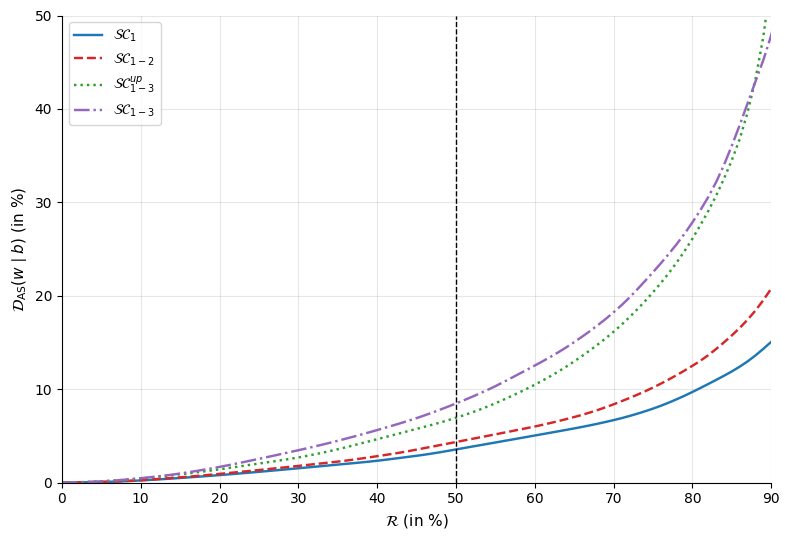

In [2]:
bond_xlsx = f"{DATA_DIR}/chap11_decarbonization_bond.xlsx"
df_as = pd.read_excel(bond_xlsx, sheet_name="AS")
x_grid = np.arange(0, 1.001, 0.01)
data_R = df_as["reduction"].to_numpy() / 100
y = np.column_stack([spline_curve(data_R, df_as.iloc[:, j].to_numpy() / 100, x_grid, scale=1e2)
                      for j in range(1, 5)])

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_four_curves(ax, x_grid, y, r"$\mathcal{D}_{\mathrm{AS}}(w \mid b)$ (in %)", (0, 50), range(0, 51, 10))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

## 2. Bond DTS tracking-error vs. reduction

From `chap11_decarbonization_bond1b.m` — sheet `DTS` of the same
workbook, fit only over $\mathcal{R}\le90\%$ (the source explicitly
drops the tail beyond 90% before fitting).

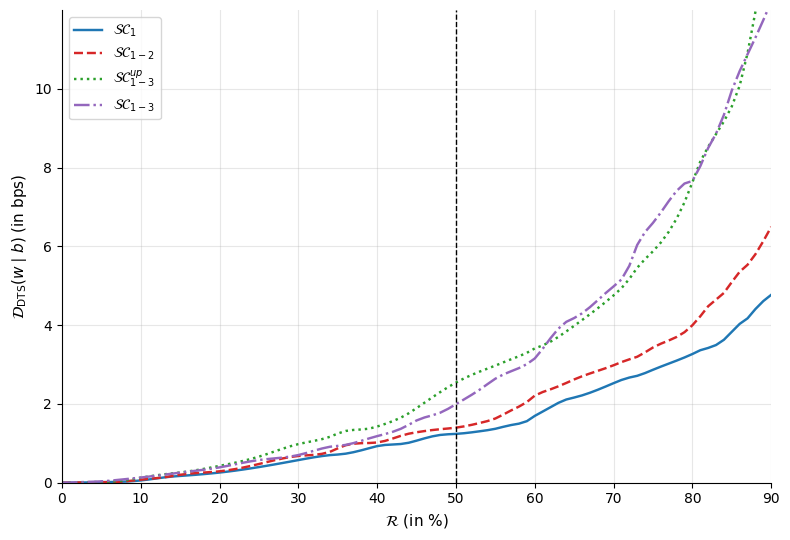

In [3]:
df_dts = pd.read_excel(bond_xlsx, sheet_name="DTS")
data_R_dts = df_dts["reduction"].to_numpy() / 100
keep = data_R_dts <= 0.90
y2 = np.column_stack([spline_curve(data_R_dts[keep], df_dts.iloc[:, j].to_numpy()[keep], x_grid)
                       for j in range(1, 5)])

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_four_curves(ax, x_grid, y2, r"$\mathcal{D}_{\mathrm{DTS}}(w \mid b)$ (in bps)", (0, 12), range(0, 12, 2))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

## 3. Equity tracking error, unconstrained CI target ($SC_0$)

From `chap11_decarbonization_equity2b.m` — one column (`$SC_0$`, the
unconstrained CI-only case) read from each of the 4 sheets
(`SC1`/`SC1_2`/`SC1_2_3_up`/`SC1_2_3`, the 4 box-constraint severities).

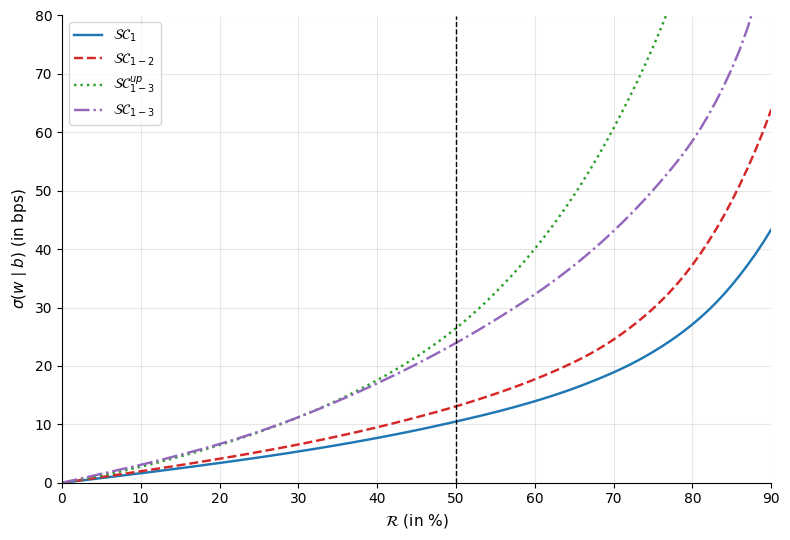

In [4]:
equity_xlsx = f"{DATA_DIR}/chap11_decarbonization_equity.xlsx"
box_sheets = ["SC1", "SC1_2", "SC1_2_3_up", "SC1_2_3"]
x_grid90 = np.arange(0, 0.901, 0.01)


def read_equity_col(sheets, col_idx):
    # col_idx is 0-based into the sheet's columns (col 0 = reduction).
    ys = []
    for sh in sheets:
        df = pd.read_excel(equity_xlsx, sheet_name=sh)
        data_R = df.iloc[:, 0].to_numpy()
        data_risk = df.iloc[:, col_idx].to_numpy() / 1e4
        ys.append(spline_curve(data_R, data_risk, x_grid90, scale=1e4))
    return np.column_stack(ys)


y3 = read_equity_col(box_sheets, 1)  # column 2 in MATLAB's 1-indexing = "$SC_0$"
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_four_curves(ax, x_grid90, y3, r"$\sigma(w \mid b)$ (in bps)", (0, 80), range(0, 81, 10))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

## 4. Equity tracking error, four $C_1$ threshold shapes

From `chap11_decarbonization_equity3e.m` — a 2x2 grid, each panel a
different $C_1$ box-threshold shape (columns 3, 4, 6, 7 across the same 4
sheets).

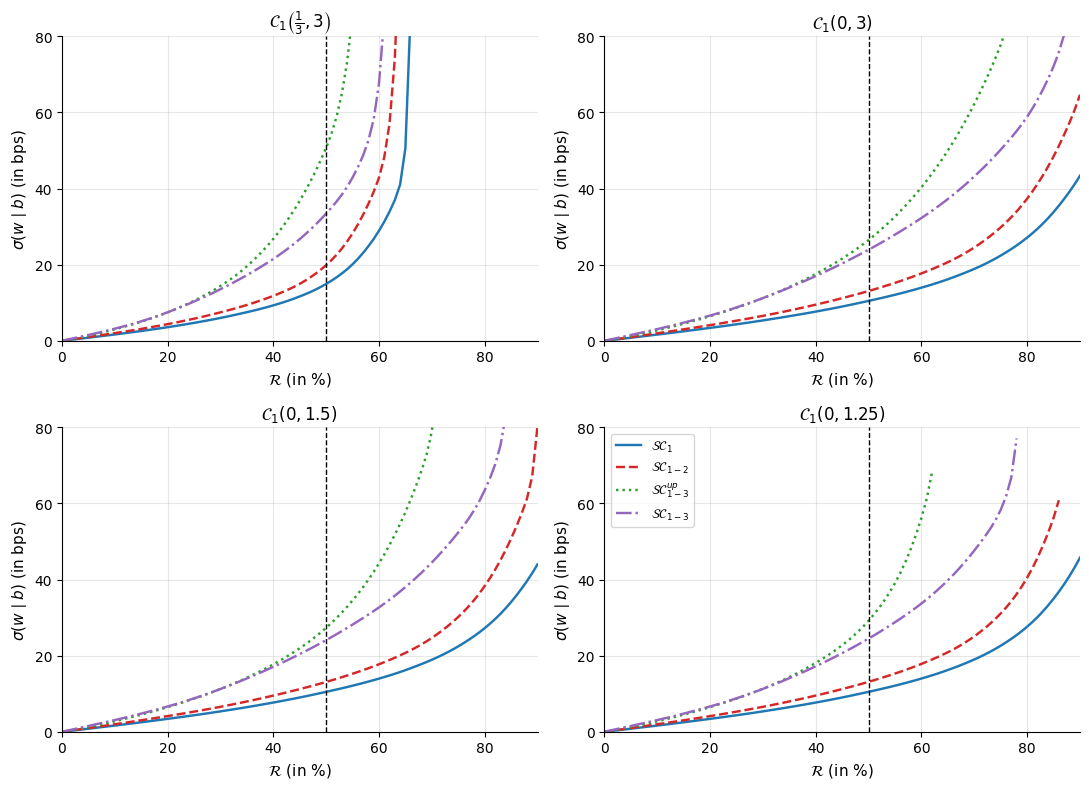

In [5]:
cols_3e = [2, 3, 5, 6]  # 0-based: MATLAB columns 3,4,6,7
titles_3e = [r"$\mathcal{C}_1\left(\frac{1}{3},3\right)$", r"$\mathcal{C}_1\left(0,3\right)$",
             r"$\mathcal{C}_1\left(0,1.5\right)$", r"$\mathcal{C}_1\left(0,1.25\right)$"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for j, (ax, col, title) in enumerate(zip(axes.flat, cols_3e, titles_3e)):
    y = read_equity_col(box_sheets, col)
    plot_four_curves(ax, x_grid90, y, r"$\sigma(w \mid b)$ (in bps)", (0, 80), range(0, 81, 20),
                      xticks=range(0, 91, 20), title=title)
    if j == 3:
        ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## 5. Equity tracking error, $C_2$/$C_3$ threshold shapes

From `chap11_decarbonization_equity4e.m` — same 2x2 layout, now columns
8-11 (the $C_2$/$C_3$ constraint family).

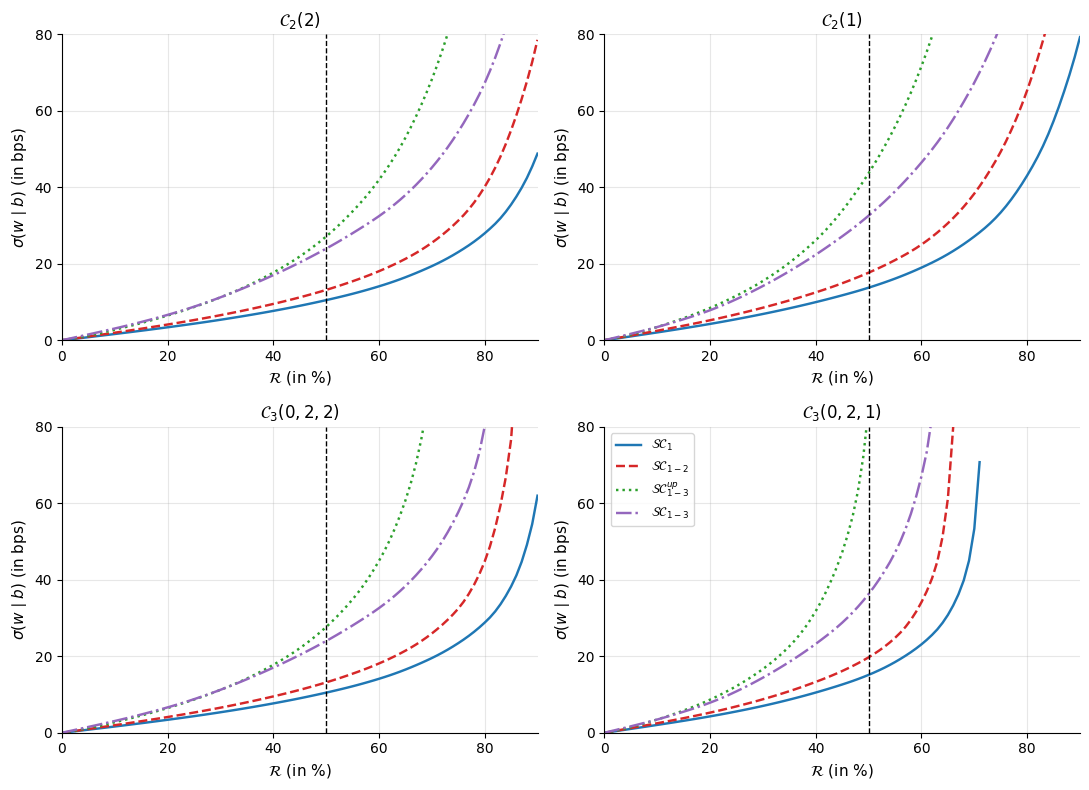

In [6]:
cols_4e = [7, 8, 9, 10]  # 0-based: MATLAB columns 8,9,10,11
titles_4e = [r"$\mathcal{C}_2\left(2\right)$", r"$\mathcal{C}_2\left(1\right)$",
             r"$\mathcal{C}_3\left(0,2,2\right)$", r"$\mathcal{C}_3\left(0,2,1\right)$"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for j, (ax, col, title) in enumerate(zip(axes.flat, cols_4e, titles_4e)):
    y = read_equity_col(box_sheets, col)
    plot_four_curves(ax, x_grid90, y, r"$\sigma(w \mid b)$ (in bps)", (0, 80), range(0, 81, 20),
                      xticks=range(0, 91, 20), title=title)
    if j == 3:
        ax.legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## 6. Equity tracking error, $C_3(0,10,2)$

From `chap11_decarbonization_equity5b.m`. Unlike Sections 3-5, this one
reads all 4 box-severity columns from a **single** sheet
(`C3(0,10,2)`, MATLAB sheet index 13) rather than one column from each of
4 sheets — the source's own fallback path (`use_xls_results=1`) is used
here in place of its default path, which loads a `.mat` checkpoint that
is not present anywhere in the shipped archive.

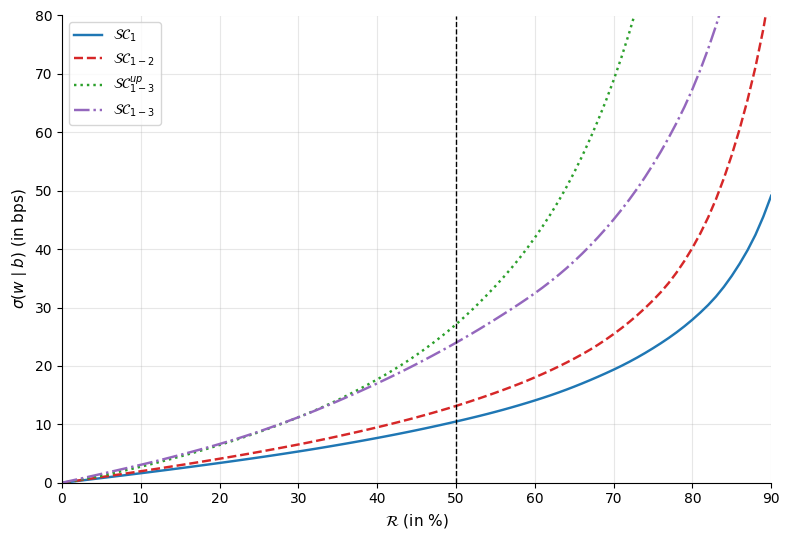

In [7]:
df_5b = pd.read_excel(equity_xlsx, sheet_name="C3(0,10,2)")
data_R_5b = df_5b.iloc[:, 0].to_numpy()
y6 = np.column_stack([spline_curve(data_R_5b, df_5b.iloc[:, j].to_numpy() / 1e4, x_grid90, scale=1e4)
                       for j in range(1, 5)])

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_four_curves(ax, x_grid90, y6, r"$\sigma(w \mid b)$ (in bps)", (0, 80), range(0, 81, 10))
ax.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.show()

## Data-blocked scripts (28 of 34 in this family)

`decarbonization5`, `decarbonization_equity1a`-`1c`, `equity2a`/`2c`,
`equity3a`-`3d`, `equity4a`-`4d`, `equity5a`, `equity6a`-`6e`, `equity7a`-
`7d` all require running the underlying optimization from scratch against
`data/chap11_MSCI_World` (a stock-level MSCI World holdings/emissions/
covariance dataset), which is not present anywhere in the shipped
archive, and none of them have a precomputed-results fallback the way the
six scripts above do — `equity2c`/`7c`/`7d` specifically need a missing
`.mat` checkpoint (`Results/chap11_decarbonization_equity2a.mat` /
`equity7a.mat`) with no `.xlsx` sheet coded as a fallback. These are
skipped entirely rather than faked with synthetic data.